In [1]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
data_long = pd.read_csv("../data/reduced_m5_dataset.csv")
data_long["date"] = pd.to_datetime(data_long["date"])
start_date = data_long["date"].min()
data_long["date"] = data_long["date"].apply(lambda x: (x - start_date).days + 1)

In [3]:
data_long["sold"].describe()

count    776400.000000
mean          1.105095
std           3.509568
min           0.000000
25%           0.000000
50%           0.000000
75%           1.000000
max         196.000000
Name: sold, dtype: float64

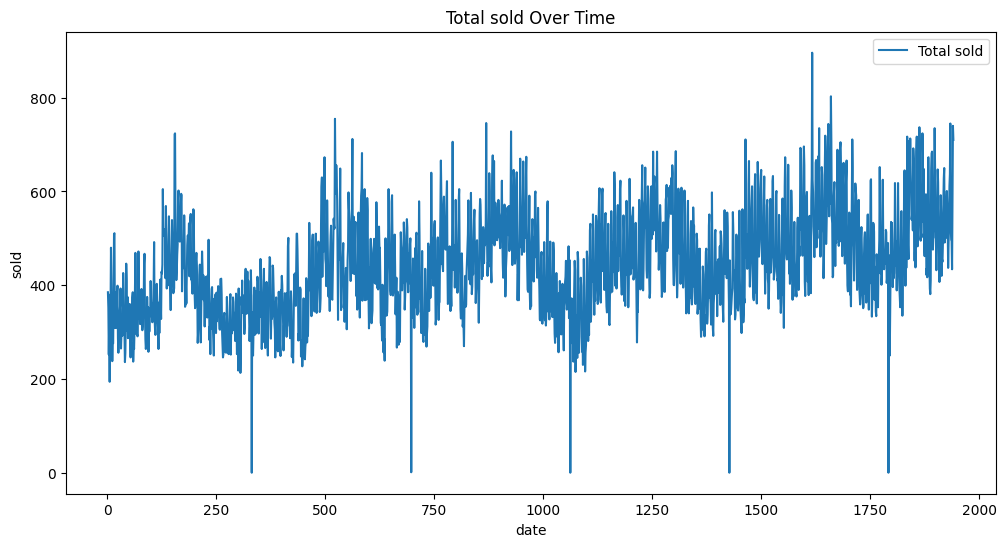

In [4]:

# Total sold over time
sold_over_time = data_long.groupby("date")["sold"].sum()
plt.figure(figsize=(12, 6))
plt.plot(sold_over_time, label="Total sold")
plt.title("Total sold Over Time")
plt.xlabel("date")
plt.ylabel("sold")
plt.legend()
plt.show()


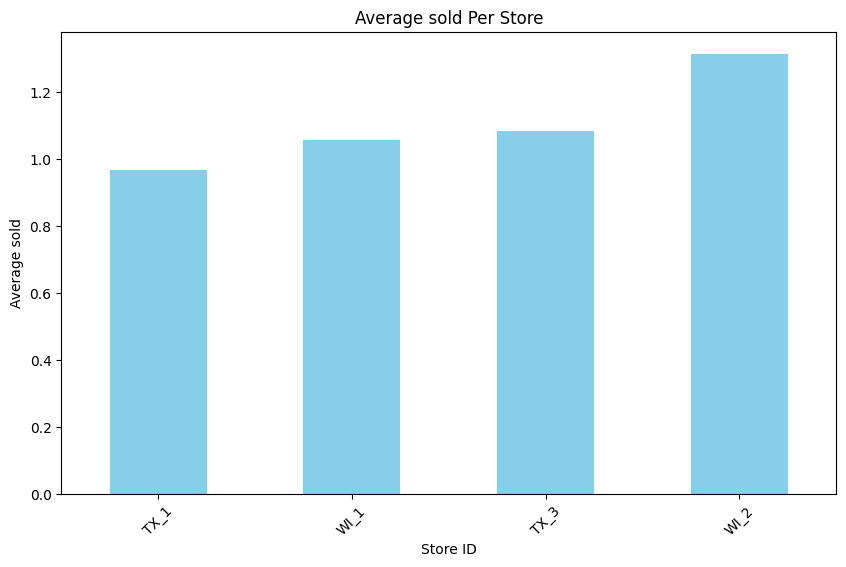

In [13]:

# Average sold per store
average_sold_per_store = data_long.groupby("store_id")["sold"].mean().sort_values()
plt.figure(figsize=(10, 6))
average_sold_per_store.plot(kind="bar", color="skyblue")
plt.title("Average sold Per Store")
plt.xlabel("Store ID")
plt.ylabel("Average sold")
plt.xticks(rotation=45)
plt.show()


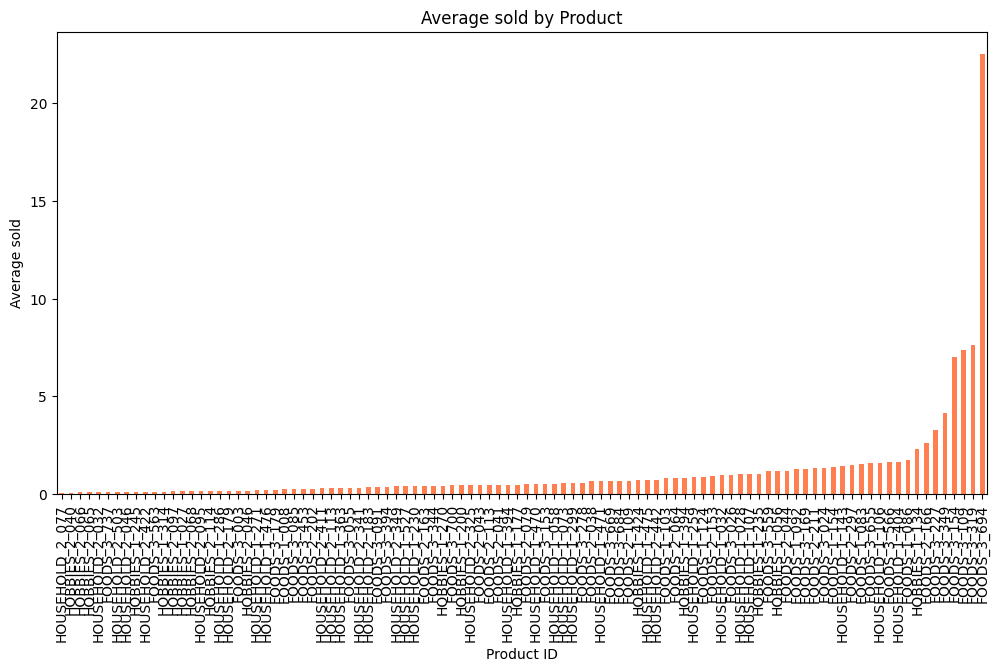

In [14]:
# Average sold by product
average_product_sold = data_long.groupby("item_id")["sold"].mean().sort_values()
plt.figure(figsize=(12, 6))
average_product_sold.plot(kind="bar", color="coral")
plt.title("Average sold by Product")
plt.xlabel("Product ID")
plt.ylabel("Average sold")
plt.xticks(rotation=90)
plt.show()

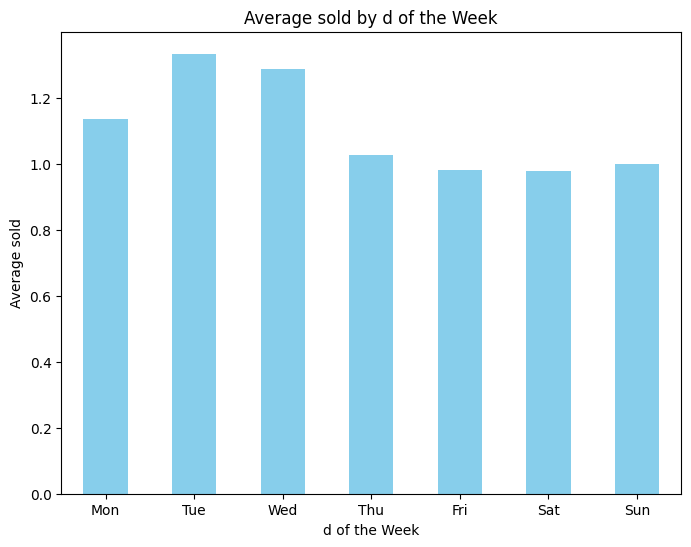

In [9]:
# Weekly seasonality
weekly_sold = data_long.groupby(data_long["date"] % 7)["sold"].mean()
plt.figure(figsize=(8, 6))
weekly_sold.plot(kind="bar", color="skyblue")
plt.title("Average sold by d of the Week")
plt.xlabel("d of the Week")
plt.ylabel("Average sold")
plt.xticks(ticks=range(7), labels=["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"], rotation=0)
plt.show()

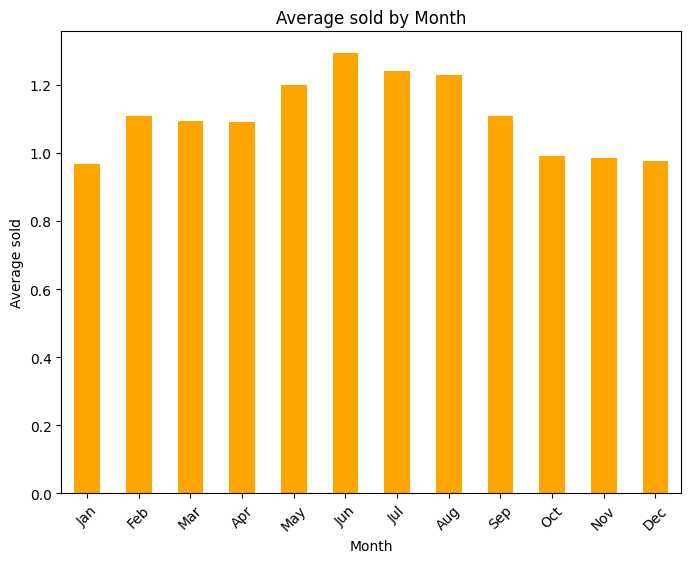

In [10]:
# Monthly seasonality
monthly_sold = data_long.groupby((data_long["date"] // 30) % 12)["sold"].mean()  # Approximate month
plt.figure(figsize=(8, 6))
monthly_sold.plot(kind="bar", color="orange")
plt.title("Average sold by Month")
plt.xlabel("Month")
plt.ylabel("Average sold")
plt.xticks(ticks=range(12), labels=["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"], rotation=45)
plt.show()

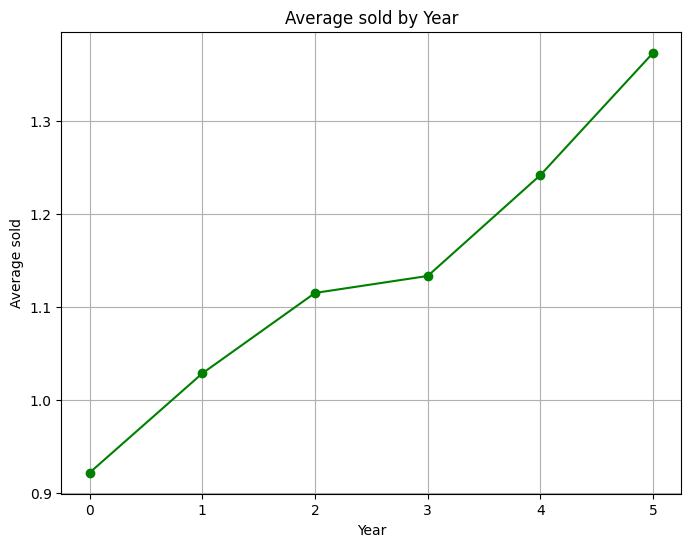

In [11]:

# Yearly seasonality
yearly_sold = data_long.groupby(data_long["date"] // 365)["sold"].mean()  # Assuming a year has 365 ds
plt.figure(figsize=(8, 6))
yearly_sold.plot(kind="line", marker="o", color="green")
plt.title("Average sold by Year")
plt.xlabel("Year")
plt.ylabel("Average sold")
plt.grid()
plt.show()